# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [31]:
# importar librerías
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [32]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [33]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [34]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

In [35]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [36]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [37]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [38]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [39]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [40]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [41]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

*En el dataset "users" podemos observar que la columna "city" tienes 469 valores faltantes, es decir, el 11,7% de los datos mientras "churn_date" tiene 3534 valores ausentes, es decir, el 88,3% de los datos.

*En el dataset "usage" podemos observar que las columnas "date" tienes 50 valores faltantes, es decir, el 0,125% de los datos mientras "duration" tiene 22076 valores ausentes, es decir, el 55,1% de los datos. al
mismo tiempo la columna "length"  tiene 17896 valores ausentes, es decir, el 44,7%.

- Indica qué harías: ¿imputar, eliminar, ignorar?
  
*En el dataset "users" se recomienda ignorar o eliminar la columna "churn_date" con el 88,3% de los valores ausentes. y se busca investigar para imputar la columna "city" con el 11,7% de los valores ausentes.

*En el dataset "usage" se recomienda dejar como nulos la columna "dates" con el 0,125% de los valores ausentes. y se busca investigar para imputar la columna "duration" con el 55,1% de los valores ausentes, al igual que la columna "length" con el 44,7% de valores ausentes.



### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [42]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene exactamente 4000 valores en un ID secuencial claro 
- La columna `age` tiene un valor minimo de -999 lo cual representa un claro sentinel o valor nulo.
  Al mismo tiempo, la diferencia entre la media (33.7) y la mediana de (47)suguere que la media está sesgada hacia la izquierda (valores más bajos) debido a la presencia  de estos valores negativos extremos. La deviacion estandar (123) es excesivamente alta para una variable de edad, lo que demuestra la existencia de outliers extremos. Aun asi, el 50% central de los usuarios tiene edad perfectamente razonables entre los 32 y 63 años como muestran los quartiles Q1- Q3: 32-63. Finalmente, el valor máximo registrado es 79 años, lo cual se encuentra dentro de un rango plausible para esta variable.

In [43]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestra una secuencia clara y es consistente con el dataset 'users' anterior
  
- Las columna `duration` presenta un 55,2% de valores nulos y un valor mínimo de 0 minutos, lo que probablemente corresponde a registros fallidos o sesiones sin actividad. Además, la diferencia entre la mediana (3.5) y la media (5.2) indica una distribución sesgada hacia la derecha, probablemente causada por la presencia de sesiones con duraciones considerablemente largas. El valor máximo de 120 minutos resulta plausible y podría corresponder a un límite establecido por el sistema. Asimismo, la desviación estándar (6.84), al ser superior a la mediana (3.5), confirma una alta variabilidad en el comportamiento de las sesiones.

- Las columna `length` presenta un 44,7% de valores nulos. Su valor mínimo es 0 y el máximo alcanza 1,490, lo que evidencia un rango extremadamente amplio. Al mismo tiempo, la proximidad entre la mediana (50) y la media (52) sugiere una distribución relativamente simétrica en la parte central de los datos. Sin embargo, la desviación estándar (56.6), superior a la mediana, junto con el valor máximo de 1,490, indica la presencia de valores atípicos severos en el extremo superior de la distribución.

In [44]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n{col}:")
    print(users[col].value_counts())



city:
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` muestra que la mayoria de los clientes se encuentran en las ciudades colombianas con Bogota(808), Medellin(616) y Cali(424) para un total del 42,2% de los datos, mientras las ciudades mexicanas de CDMX (730), GDL(450), y MTY (407) para un total del 39.8% de los datos. El valor '?' (2.4%) es un sentinel de dato faltante, igual al patrón del valor -999 en la columna age. 
  
- La columna `plan` muestra 2 tipos de categorias basico y premium. El plan basico muestra 2595 usuarios es decir el 64,9% mientras el plan premium muestra 1405 usuarios es decir el 35,1% de los datos. 

In [45]:

# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` cuenta con dos tipos de datos: llamadas "call" y mensajes "text". En total hay 22092 mensajes, es decir, el 55,2% y  17908 llamadas, es decir, el 44,8%. 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  
- En la columna 'age' se encuentra el valor numerico invalidos (-999), al mismo tiempo, la columna 'city' muestra el valor invalido '?'.

- ¿Qué acción tomarías?

- En la columna 'age' se recomienda remplazar '?' por pd.NA, al igual que remplazar '?' por pd.NA. 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [46]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [47]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [48]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`,  los datos se distribuyen por años de la siguiente manera: en 2022 hay 1314 registros, en 2023 hay 1316 registros, en 2024 hay 1330 registros y, finalmente, en 2026 hay 40 registros. La presencia de datos correspondientes al año 2026 posiblemente se deba a un error de captura o registro, ya que el conjunto de datos solo abarca hasta el año 2024. Asimismo, se observa una distribución casi uniforme de los registros entre los años 2022, 2023 y 2024.

In [49]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, encontramos que tenemos 39950 datos del año 2024, lo cual indica que hay 50 datos faltantes. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- se detectaron 40 registros con año 2026, que superan el límite válido de 2024.al igual que no se detectaron años muy antiguos — el mínimo es 2022, coherente con el periodo de operación del sistema.
- ¿Qué harías con ellas?
- No se imputan porque una fecha de registro incorrecta no tiene valor de referencia confiable para estimar la real — podría ser un typo (2024 → 2026) o cualquier otra cosa. Lo más seguro es tratarlas como dato faltante y excluirlas de análisis temporales.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [50]:
# Reemplazar -999 por la mediana de age
age_mediana =users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [51]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace('?', pd.NA)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [52]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
print("Distribución de años después de limpieza:")
print(users['reg_date'].dt.year.value_counts().sort_index())
print(f"\nTotal de fechas nulas: {users['reg_date'].isna().sum()}")

Distribución de años después de limpieza:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

Total de fechas nulas: 40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [78]:
# Verificación MAR en usage (Missing At Random) para duration
# Verificar si los faltantes en duration dependen del tipo de plan
usage['duration'].isna().groupby(users['plan']).mean()

# Verificar si dependen de la edad del usuario  
usage['duration'].isna().groupby(users['age']).mean()

# Verificar si dependen del país
usage['duration'].isna().groupby(users['city']).mean()

city
Bogotá      0.542079
CDMX        0.564384
Cali        0.544811
GDL         0.533333
MTY         0.565111
Medellín    0.587662
Name: duration, dtype: float64

In [79]:
# Verificación MAR en usage (Missing At Random) para length
# 1. Verificar si los faltantes en length dependen del tipo de comunicación
print("Proporción de faltantes en length por tipo:")
print(usage['length'].isna().groupby(usage['type']).mean())

# 2. Verificar si dependen del año/mes de la fecha
print("\nProporción de faltantes en length por mes:")
print(usage['length'].isna().groupby(usage['date'].dt.month).mean())

# 3. Verificar si dependen del usuario específico (muestra)
print("\nProporción de faltantes por usuario (primeros 10):")
print(usage['length'].isna().groupby(usage['user_id']).mean().head(10))

Proporción de faltantes en length por tipo:
type
call    0.99933
text    0.00000
Name: length, dtype: float64

Proporción de faltantes en length por mes:
date
1.0    0.445419
2.0    0.457598
3.0    0.442007
4.0    0.445636
5.0    0.443665
6.0    0.450328
Name: length, dtype: float64

Proporción de faltantes por usuario (primeros 10):
user_id
10000    0.300000
10001    0.666667
10002    0.285714
10003    0.214286
10004    0.428571
10005    0.583333
10006    0.625000
10007    0.625000
10008    0.500000
10009    0.375000
Name: length, dtype: float64


diagnostico de nulos en `duration` y `length` La proporción de nulos es ~54–58% en todas las ciudades de forma consistente. Esto confirma que los nulos no dependen de la ciudad — son MAR respecto a esa variable.
La causa real ya la identificamos: duration solo se llena cuando type'call', y las llamadas representan el 44.8% del dataset y asi los nulos son estructurales por diseño, no errores. los nulos en ambas columnas son MCAR/MAR por diseño del sistema — cada columna aplica solo a un tipo de evento. Imputarlos sería inventar datos sin sentido (ej. darle duración a un mensaje de texto). Lo correcto es mantenerlos como NaN y usarlos solo en el contexto de su type correspondiente.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [54]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(
    cant_mensajes        = ("is_text",   "sum"),
    cant_llamadas        = ("is_call",   "sum"),
    cant_minutos_llamada = ("duration",  "sum")
).reset_index()

users_full = users.merge(usage_agg, on="user_id", how="left")

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [55]:
# Renombrar columnas, Ya hecho arriba

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [56]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [57]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [58]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).mul(100).round(2)

Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

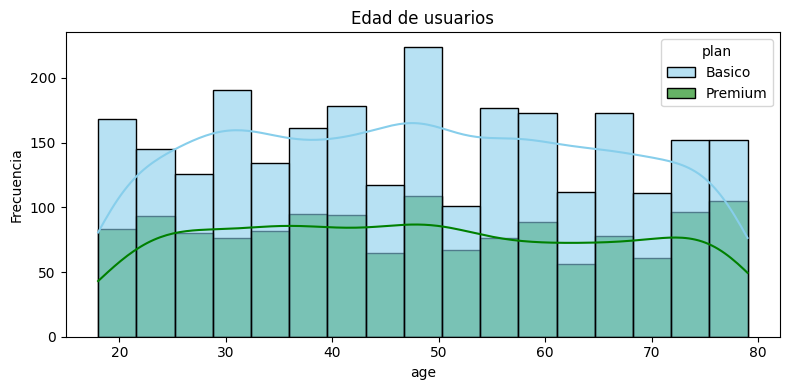

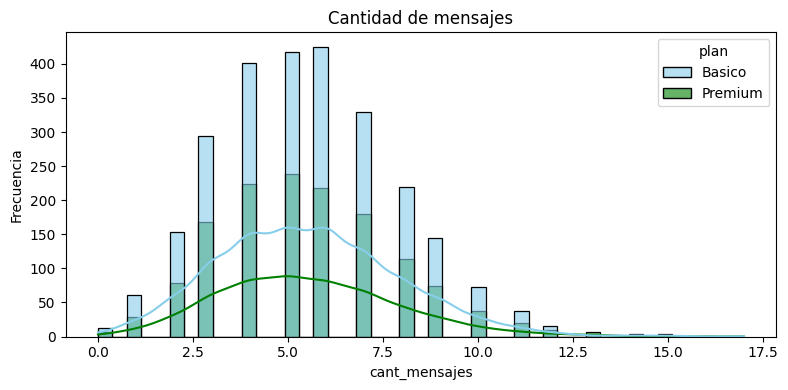

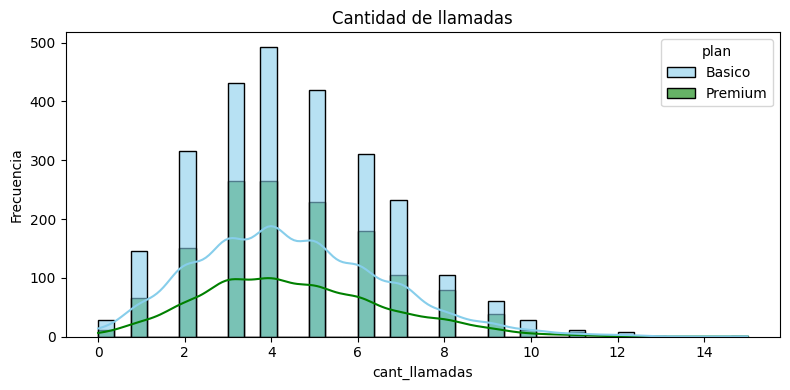

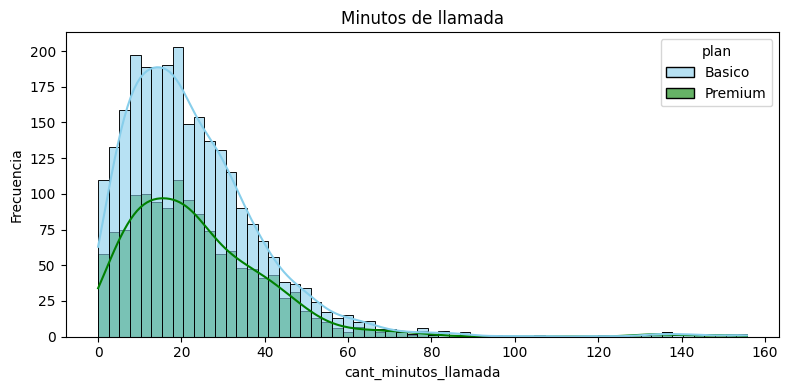

In [75]:
# Histograma para visualizar la edad (age)

import seaborn as sns
import matplotlib.pyplot as plt

palette = ['skyblue', 'green']
cols = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
titulos = ['Edad de usuarios', 'Cantidad de mensajes', 'Cantidad de llamadas', 'Minutos de llamada']

for col, titulo in zip(cols, titulos):
    plt.figure(figsize=(8, 4))
    sns.histplot(data=user_profile, x=col, hue='plan',
                 palette=palette, kde=True, alpha=0.6)
    plt.title(titulo)
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.tight_layout()
    plt.show()

💡Insights: 
- Distribuciónaproximadamente simétrica o uniforme en ambos planes. El plan Básico domina en todos los grupos de edad, lo cual es esperado dado que representa el 65% de la base. El plan Premium mantiene una presencia relativamente constante entre 20 y 75 años.

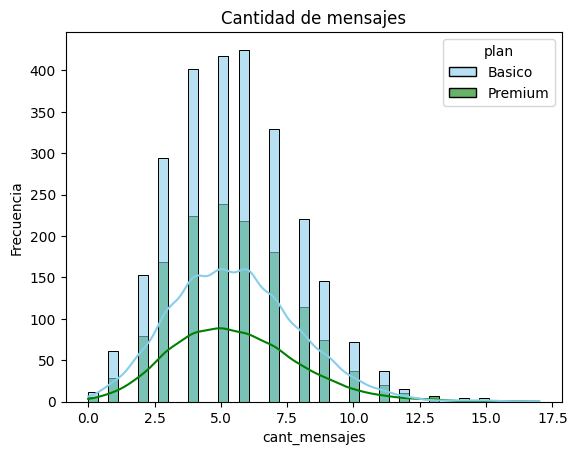

In [61]:
# Histograma para visualizar la cant_mensajes

sns.histplot(data=user_profile, x='cant_mensajes', hue='plan',
             palette=['skyblue', 'green'], kde=True, alpha=0.6)
plt.title('Cantidad de mensajes')
plt.xlabel('cant_mensajes')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- la Distribución esta sesgada a la derecha en ambos planes, la mayoría de usuarios se concentra entre 3 y 7 mensajes, con una cola larga hacia valores altos (hasta 17).Los usuarios Básico se concentran fuertemente entre 4 y 7 mensajes, con pico en 5–6. Su estimacion de densidad es más estrecha y pronunciada.Los usuarios Premium tienen una distribución más dispersa y aplanada, extendiéndose más hacia la derecha y esto indica que hay una mayor proporción de usuarios Premium con volúmenes altos de mensajes (8–15).

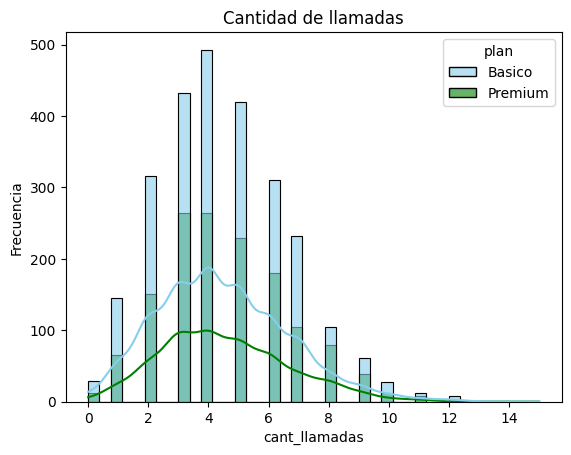

In [62]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan',
             palette=['skyblue', 'green'], kde=True, alpha=0.6)
plt.title('Cantidad de llamadas')
plt.xlabel('cant_llamadas')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- La Distribución esta sesgada a la derecha en ambos planes. La masa principal se concentra entre 2 y 6 llamadas, con cola que se extiende hasta 15.Los usuarios Básico tienen su pico en 3–4 llamadas y caen rápidamente a partir de 6 — son usuarios de bajo a medio volumen de llamadas. Los usuarios Premium tienen una distribución más ancha y desplazada hacia la derecha — su estimacion de densidad es más plana, indicando mayor presencia en rangos de 4–7 llamadas.

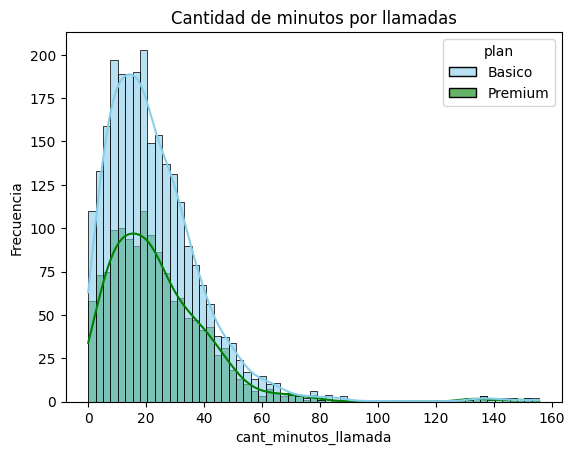

In [63]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan',
             palette=['skyblue', 'green'], kde=True, alpha=0.6)
plt.title('Cantidad de minutos por llamadas')
plt.xlabel('cant_minutos_llamada')
plt.ylabel('Frecuencia')
plt.show()


💡Insights: 
- la Distribución esta fuertemente sesgada a la derecha en ambos planes. La mayoría de usuarios acumula entre 0 y 40 minutos totales, con una cola larga que llega hasta 160 minutos (posibles outliers confirmados por el boxplot anterior).Los usuarios Básico tienen su pico entre 10 y 20 minutos y una cola que se extiende notablemente hasta 160 — hay usuarios Básico con volúmenes de minutos sorprendentemente altos. Los usuarios Premium se concentran más entre 10 y 30 minutos con una distribución más compacta

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


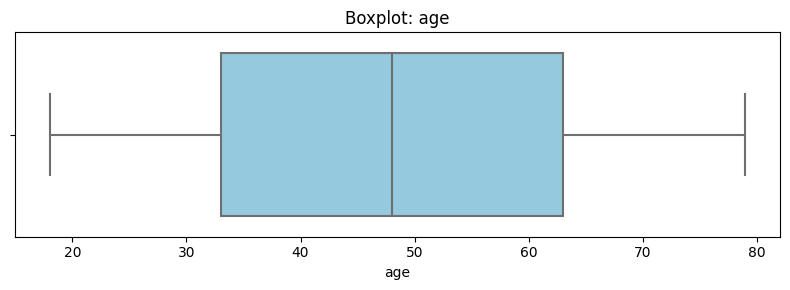

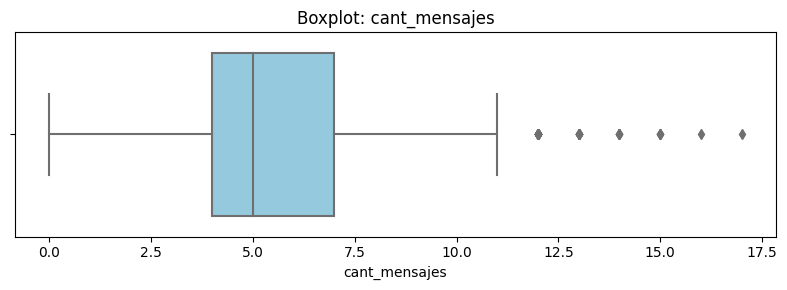

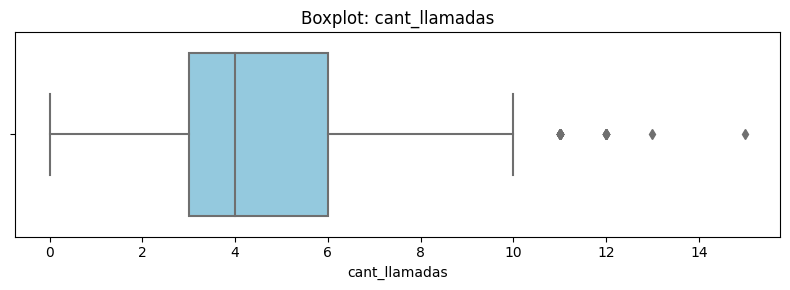

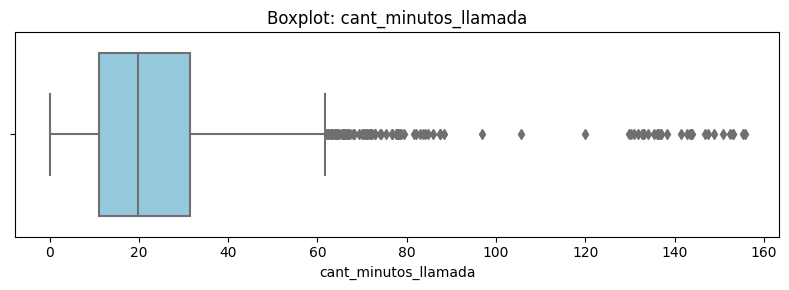

In [64]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()

💡Insights: 

La variable age presenta una distribución limpia y relativamente simétrica entre los 18 y 79 años, sin evidencia de valores atípicos. El rango intercuartílico (IQR) se encuentra aproximadamente entre 35 y 62 años, con una mediana cercana a 48, por lo que no requiere tratamiento adicional. En contraste, cant_mensajes muestra algunos valores atípicos únicamente en la cola derecha, con seis observaciones aisladas entre 12.5 y 17.5, mientras que el límite superior definido por el IQR se ubica alrededor de 11; estos casos representan usuarios con una actividad más alta de lo habitual, pero parecen corresponder a comportamientos reales. Un patrón similar se obse
rva en cant_llamadas, donde aparecen cuatro valores atípicos entre 11 y 15 llamadas, indicando también usuarios con un uso excepcionalmente elevado. Finalmente, cant_minutos_llamada es la variable con mayor nivel de preocupación, ya que presenta una gran cantidad de valores atípicos severos: los puntos comienzan aproximadamente en 62 minutos y se extienden hasta 160, con una alta concentración entre 62 y 90 minutos, lo que sugiere una distribución fuertemente sesgada

In [65]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(f"{col}: límite superior = {limite_superior:.2f}")



cant_mensajes: límite superior = 11.50
cant_llamadas: límite superior = 10.50
cant_minutos_llamada: límite superior = 61.86


In [66]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

Las variables cant_mensajes y cant_llamadas pueden mantenerse sin aplicar tratamientos adicionales sobre los valores atípicos. En cant_mensajes, el límite superior definido por el IQR es 11.5 y el valor máximo alcanza 17, una diferencia de únicamente 5.5 unidades, lo que sugiere usuarios con una actividad elevada pero realista y no errores de captura. Eliminar estos casos implicaría perder información relevante sobre el segmento de usuarios más activos. De manera similar, cant_llamadas presenta un límite IQR de 10.5 y un máximo de 15, una diferencia reducida y completamente plausible para usuarios con un uso intensivo del servicio, por lo que no existe una justificación técnica para excluir estos registros. Por otro lado, cant_minutos_llamada requiere un tratamiento mediante winsorizing (aplicación de un límite o cap), debido a la presencia de valores extremos más pronunciados. El límite superior del IQR se sitúa en 61.86 minutos, mientras que el valor máximo alcanza 155.69 minutos, generando una diferencia cercana a 94 minutos. Además, la desviación estándar (18.16) es muy cercana a la mediana (19.78), reflejando una elevada dispersión. Estos valores extremos influyen considerablemente sobre la media (23.3 frente a una mediana de 19.78), sesgando la distribución y afectando la representatividad de las medidas descriptivas.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [68]:

# Crear columna grupo_uso
import numpy as np
conditions = [
    (user_profile['cant_llamadas'] < 5)  & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]
choices = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(conditions, choices, default='Alto uso')

user_profile['grupo_uso'].value_counts()


Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

In [69]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [70]:
# Crear columna grupo_edad
conditions = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]
choices = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(conditions, choices, default='Adulto Mayor')

user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

In [71]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

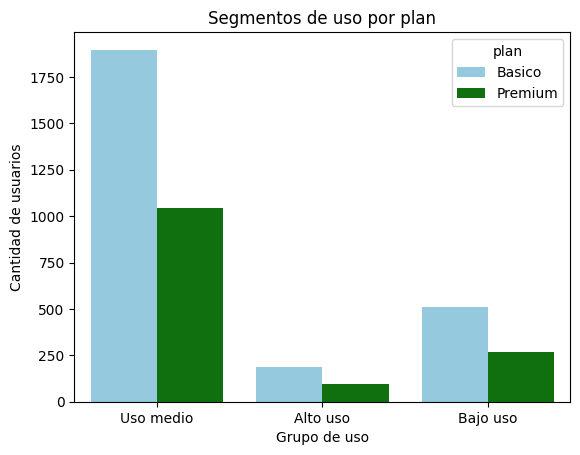

In [73]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', hue='plan',
              palette=['skyblue', 'green'])
plt.title('Segmentos de uso por plan')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')

plt.show()

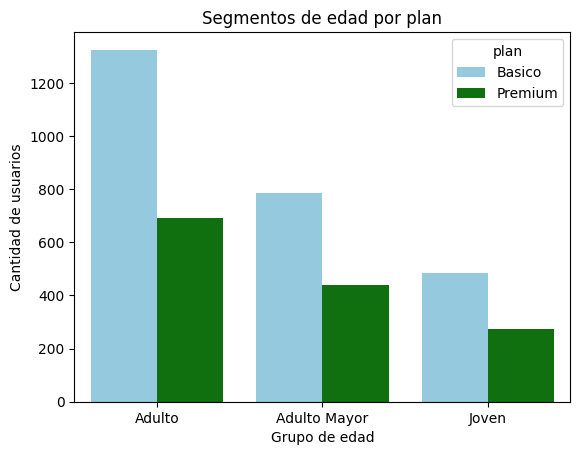

In [74]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', hue='plan',
              palette=['skyblue', 'green'])
plt.title('Segmentos de edad por plan')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- age con valor centinela -999: afectó a usuarios cuya edad era inválida — reemplazados por la mediana (47 años) para no distorsionar el análisis.
- city con valor "?": 96 registros (2.4% de 4,000 usuarios) sin ciudad identificable — reemplazados por NaN y excluidos de análisis geográfico.
- reg_date con años futuros: 40 registros (1.0%) con año 2026, imposible dado que los datos llegan hasta 2024 — marcados como nulos.
- cant_minutos_llamada con outliers extremos: valores de hasta 155 minutos cuando el límite IQR era 61.86 — aplicado cap para evitar distorsión en métricas de uso.
- duration y length con nulos masivos: 55% y 45% respectivamente — confirmados como MAR estructural (cada columna aplica solo a su tipo de evento), no errores.


🔍 **Segmentos por Edad**
- La edad no diferencia el plan elegido — Básico y Premium se distribuyen uniformemente de 18 a 79 años, sin franja etaria dominante en Premium.
- Los tres grupos (Joven <30, Adulto 30–60, Adulto Mayor >60) coexisten en ambos planes en proporciones similares, lo que indica que la decisión de plan no está guiada por la edad sino por el comportamiento de uso. 


📊 **Segmentos por Nivel de Uso**
- Bajo uso (llamadas <5 y mensajes <5): mayoritariamente plan Básico — usuarios que consumen poco y probablemente no perciben valor en Premium.
- Uso medio (llamadas <10 y mensajes <10): mezcla de ambos planes — zona de transición donde convive el usuario Básico activo con el Premium moderado.
- Alto uso (llamadas ≥10 o mensajes ≥10): predominantemente Premium — usuarios que explotan el servicio y justifican económicamente el plan superior.

➡️ Esto sugiere que el nivel de uso es el predictor más fuerte del plan, no la edad ni la ciudad. Los usuarios Básico de uso medio son el segmento con mayor potencial de conversión a Premium — ya tienen el comportamiento, solo falta el incentivo.

💡 **Recomendaciones**
- Campaña de conversión dirigida a usuarios Básico de uso medio: aquellos con 6–10 mensajes o llamadas son candidatos naturales a Premium — ofrecerles un upgrade con descuento del primer mes podría acelerar la conversión.
- Crear un plan intermedio "Estándar": la brecha entre Básico y Premium es grande; un plan con límites moderados (ej. hasta 8 mensajes y 8 llamadas) captura usuarios que hoy se quedan en Básico por precio, no por uso.
- Investigar usuarios Básico con minutos extremos: el patrón de pocas llamadas pero muy largas en Básico sugiere un segmento que usa el servicio intensivamente en duración — un plan "Básico Plus" orientado a minutos podría retenerlos y monetizarlos mejor.
- Limpiar el sistema de captura de datos: los centinelas -999, "?" y fechas futuras apuntan a un problema de validación en origen — implementar restricciones en el formulario/CRM evitaría estos errores en futuros periodos.
- Análisis geográfico pendiente: con el 2.4% de ciudades desconocidas resuelto, vale la pena cruzar city × plan para detectar mercados con baja penetración Premium y enfocar esfuerzos comerciales allí.


---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`